# Audit Overfitting — Apakah Strategi Notebook 07 Cuma "Menghafal"?

Notebook 07 menemukan strategi **Tren + Momentum Rotasi** (F2) dengan hasil uji +204% (Konservatif)
vs BTC +32%. Hasil sebagus itu wajib dicurigai. Notebook ini menguji apakah hasilnya **overfit**
(cocok dengan data masa lalu tapi tidak berlaku ke depan).

| # | Uji | Pertanyaan |
|---|---|---|
| 1 | Audit kebocoran proses | Apakah pemilihan di 07 ikut "mengintip" data uji? |
| 2 | **PBO / CSCV** (Bailey et al. 2015) | Seberapa sering konfigurasi terbaik in-sample jadi di bawah median out-of-sample? |
| 3 | **Deflated Sharpe Ratio** (Bailey & López de Prado 2014) | Apakah Sharpe tetap signifikan setelah dikoreksi ~300 percobaan? |
| 4 | **Walk-forward** tahunan | Kalau parameter dipilih ulang tiap tahun pakai data lalu saja, hasilnya? |
| 5 | **Uji nol: pilihan acak** | Apakah ranking momentum lebih baik dari memilih coin acak dengan filter yang sama? |
| 6 | **Tanpa SUI dari awal** | Kalau proses riset 07 diulang tanpa coin yang dicurigai bias? |
| 7 | **Bootstrap** Sharpe | Seberapa lebar ketidakpastian Sharpe periode uji? |
| 8 | Eksekusi circuit breaker di open besok | Apakah circuit breaker di 07 terlalu optimis? |

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "notebooks"))

import warnings
warnings.filterwarnings("ignore")

import itertools
from math import comb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from data_source.loader import load_symbol, discover_symbols
from research.single_position import Panel, run, metrics, f2_target, pretty, BTC

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 30)

TRAIN = ("2021-01-01", "2023-12-31")
TEST = ("2024-01-01", "2026-06-30")
FULL = ("2021-01-01", "2026-06-30")
ohlc_all = {s: load_symbol(s, "1d", "full") for s in ["ADAUSDT", "AVAXUSDT", "BNBUSDT", "BTCUSDT", "DOGEUSDT", "ETHUSDT", "HBARUSDT", "SOLUSDT", "SUIUSDT", "XRPUSDT"]}
P = Panel(ohlc_all, "2018-01-01", "2026-06-30")

# Konfigurasi hasil notebook 07
CFG = {"Konservatif": dict(ma_n=50, L=14, R=1, tv=0.02, cdd=0.15),
       "Agresif": dict(ma_n=50, L=14, R=1, tv=0.03, cdd=0.15)}
GRID = list(itertools.product((50, 100), (14, 30), (1, 3, 7), (0.0, 0.02, 0.03), (0.0, 0.15, 0.20, 0.25)))
GRID_KEYS = ["ma_n", "L", "R", "tv", "cdd"]


def sim(Pn, c, start, end, **kw):
    tgt = f2_target(Pn, c["ma_n"], c["L"], c["R"])
    size = (c["tv"] / Pn.vol(20)).clip(upper=1) if c["tv"] else None
    return run(Pn, tgt, start, end, size=size, circuit_dd=c["cdd"] or None, **kw)


def daily_sharpe(r):
    r = np.asarray(r)
    return r.mean() / r.std() if r.std() > 0 else 0.0


btc_test = metrics(*run(P, pd.Series(BTC, index=P.dates), *TEST))
print("Konfigurasi 07:", CFG)
print(f"{len(GRID)} kombinasi grid F2 | BTC test: {btc_test['total_return']:+.1%}, Sharpe {btc_test['sharpe']:.2f}")

Konfigurasi 07: {'Konservatif': {'ma_n': 50, 'L': 14, 'R': 1, 'tv': 0.02, 'cdd': 0.15}, 'Agresif': {'ma_n': 50, 'L': 14, 'R': 1, 'tv': 0.03, 'cdd': 0.15}}
144 kombinasi grid F2 | BTC test: +32.3%, Sharpe 0.47


## 1. Audit kebocoran proses riset notebook 07

Di notebook 07, tabel screening menampilkan kolom **train dan test** berdampingan saat keluarga F2 dipilih.
Itu celah: pilihan bisa terpengaruh hasil uji. Cek ulang: **kalau hanya memakai data latih**, keluarga
mana yang menang? Pemilihan parameter (Calmar latih tertinggi) sudah murni data latih.

In [2]:
btc_close = P.close[BTC]
hold = pd.Series(BTC, index=P.dates)
fam_rows = []
for n in (20, 30, 50, 75, 100, 150, 200):
    for kind in ("sma", "ema"):
        ma = btc_close.rolling(n, min_periods=n).mean() if kind == "sma" else btc_close.ewm(span=n, min_periods=n).mean()
        for trail in (None, 3.0):
            fam_rows.append(("F1 tren BTC", metrics(*run(P, hold.where(btc_close > ma), *TRAIN, trail_atr=trail))["sharpe"]))
for n, L in itertools.product((50, 100), (14, 30, 60)):
    for trail in (None, 3.0):
        fam_rows.append(("F2 tren+momentum", metrics(*run(P, f2_target(P, n, L, 1), *TRAIN, trail_atr=trail))["sharpe"]))
for N, M in itertools.product((20, 40, 55), (10, 20)):
    hi = P.high[BTC].rolling(N, min_periods=N).max().shift(1)
    lo = P.low[BTC].rolling(M, min_periods=M).min().shift(1)
    state, s = [], None
    for c, h, l in zip(btc_close, hi, lo):
        s = BTC if (s is None and c > h) else (None if (s is not None and c < l) else s)
        state.append(s)
    fam_rows.append(("F3 breakout BTC", metrics(*run(P, pd.Series(state, index=P.dates), *TRAIN))["sharpe"]))
fam = pd.DataFrame(fam_rows, columns=["family", "train_sharpe"]).groupby("family")["train_sharpe"].agg(["median", "max", "size"])
print("Ranking keluarga HANYA dari data latih (F4 sudah negatif di latih, lihat 07):")
fam.sort_values("median", ascending=False).round(2)

Ranking keluarga HANYA dari data latih (F4 sudah negatif di latih, lihat 07):


,median,max,size
family,,,
F2 tren+momentum,1.17,1.43,12
F1 tren BTC,0.79,1.39,28
F3 breakout BTC,0.52,0.77,6


## 2. Probability of Backtest Overfitting (PBO) — CSCV

Metode Bailey, Borwein, López de Prado & Zhu (2015):
1. Return harian 144 konfigurasi F2 selama 2021-01 → 2026-06 dipotong jadi **S = 16 blok waktu**.
2. Untuk **setiap** cara membagi 16 blok jadi 8 "in-sample" + 8 "out-of-sample" (12.870 kombinasi):
   pilih konfigurasi dengan Sharpe in-sample terbaik → lihat peringkatnya di out-of-sample.
3. **PBO** = persentase kasus di mana konfigurasi "juara" in-sample jatuh **di bawah median**
   out-of-sample. PBO ≈ 50% = pemilihan tidak lebih baik dari acak (overfit total); PBO < 10–20% = bagus.

Kombinasi CSCV: 12,870 (C(16,8) = 12,870)
PBO = 37.2%   (≈50% = overfit total, <20% = bagus)
Sharpe juara in-sample (median)       : 1.95
Sharpe juara itu di out-of-sample     : 1.28
Median Sharpe semua konfigurasi di OOS: 1.23
Peluang juara in-sample RUGI di OOS   : 1.0%


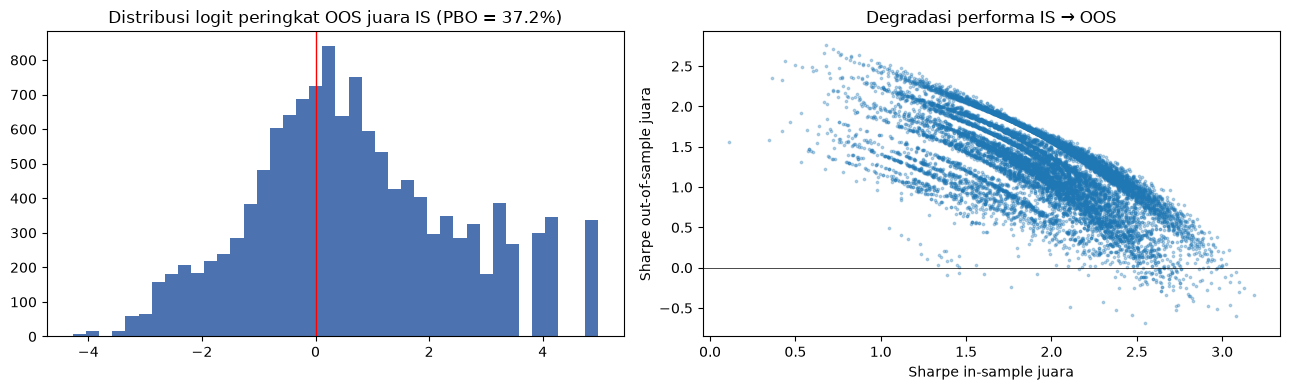

In [3]:
eq_full = {}
for combo in GRID:
    c = dict(zip(GRID_KEYS, combo))
    _, eq = sim(P, c, *FULL)
    eq_full[combo] = eq.pct_change().fillna(0.0)
R_mat = pd.DataFrame(eq_full)          # [hari x 144 konfigurasi]
T, K = R_mat.shape
S = 16
blocks = np.array_split(np.arange(T), S)
X = R_mat.to_numpy()
bsum = np.array([X[b].sum(0) for b in blocks])          # [S x K]
bsq = np.array([(X[b] ** 2).sum(0) for b in blocks])
bn = np.array([len(b) for b in blocks])

logits, is_best, oos_of_best, oos_median = [], [], [], []
for is_idx in itertools.combinations(range(S), S // 2):
    is_idx = list(is_idx)
    oos_idx = [b for b in range(S) if b not in is_idx]
    def sharpe(idx):
        n = bn[idx].sum(); m = bsum[idx].sum(0) / n
        v = bsq[idx].sum(0) / n - m ** 2
        return m / np.sqrt(np.maximum(v, 1e-18))
    sr_is, sr_oos = sharpe(is_idx), sharpe(oos_idx)
    best = int(np.argmax(sr_is))
    rank = stats.rankdata(sr_oos)[best] / (K + 1)          # 0..1, 1 = terbaik di OOS
    logits.append(np.log(rank / (1 - rank)))
    is_best.append(sr_is[best]); oos_of_best.append(sr_oos[best]); oos_median.append(np.median(sr_oos))
logits = np.array(logits)
pbo = (logits <= 0).mean()
ann = np.sqrt(365)
print(f"Kombinasi CSCV: {len(logits):,} (C({S},{S//2}) = {comb(S, S//2):,})")
print(f"PBO = {pbo:.1%}   (≈50% = overfit total, <20% = bagus)")
print(f"Sharpe juara in-sample (median)       : {np.median(is_best) * ann:.2f}")
print(f"Sharpe juara itu di out-of-sample     : {np.median(oos_of_best) * ann:.2f}")
print(f"Median Sharpe semua konfigurasi di OOS: {np.median(oos_median) * ann:.2f}")
print(f"Peluang juara in-sample RUGI di OOS   : {(np.array(oos_of_best) < 0).mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(logits, bins=40, color="#4C72B0")
axes[0].axvline(0, color="red", lw=1)
axes[0].set_title(f"Distribusi logit peringkat OOS juara IS (PBO = {pbo:.1%})")
axes[1].scatter(np.array(is_best) * ann, np.array(oos_of_best) * ann, s=3, alpha=0.3)
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_xlabel("Sharpe in-sample juara"); axes[1].set_ylabel("Sharpe out-of-sample juara")
axes[1].set_title("Degradasi performa IS → OOS")
plt.tight_layout(); plt.show()

## 3. Deflated Sharpe Ratio (DSR)

Semakin banyak konfigurasi dicoba, semakin besar peluang menemukan Sharpe tinggi **secara kebetulan**.
DSR menghitung peluang Sharpe strategi terpilih *benar-benar* > 0 setelah dikoreksi jumlah percobaan
(N), skewness, dan kurtosis return.

Jumlah percobaan jujur selama riset 07 (termasuk prototipe yang tidak dicatat di notebook):
screening 54 + grid F2 awal 108 + grid F2 akhir 144 + momentum awal 32 ≈ **338**.
DSR > 95% = signifikan.

In [4]:
def expected_max_sharpe(n_trials, var_sr):
    g = 0.5772156649
    return np.sqrt(var_sr) * ((1 - g) * stats.norm.ppf(1 - 1 / n_trials) + g * stats.norm.ppf(1 - 1 / (n_trials * np.e)))


def dsr(returns, sr_benchmark):
    r = np.asarray(returns)
    sr = daily_sharpe(r)
    sk, ku = stats.skew(r), stats.kurtosis(r, fisher=False)
    z = (sr - sr_benchmark) * np.sqrt(len(r) - 1) / np.sqrt(1 - sk * sr + (ku - 1) / 4 * sr ** 2)
    return stats.norm.cdf(z), sr


# variansi Sharpe antar percobaan: dari 144 konfigurasi di periode uji
test_mask = (R_mat.index >= TEST[0]) & (R_mat.index <= TEST[1])
var_sr = np.var([daily_sharpe(R_mat.loc[test_mask, k]) for k in R_mat.columns])
rows = []
for name, c in CFG.items():
    _, eq = sim(P, c, *TEST)
    r = eq.pct_change().dropna()
    for n_trials in (1, 50, 338, 1000):
        sr0 = expected_max_sharpe(n_trials, var_sr) if n_trials > 1 else 0.0
        prob, sr = dsr(r, sr0)
        rows.append(dict(strategi=name, n_percobaan=n_trials, sharpe_tahunan=sr * np.sqrt(365),
                         batas_sharpe_kebetulan=sr0 * np.sqrt(365), DSR=prob))
pretty(pd.DataFrame(rows).set_index(["strategi", "n_percobaan"]), pct=["DSR"], dec=["sharpe_tahunan", "batas_sharpe_kebetulan"])

sharpe_tahunan batas_sharpe_kebetulan     DSR
strategi    n_percobaan                                              
Konservatif 1                     1.37                   0.00  +99.2%
            50                    1.37                   0.67  +89.4%
            338                   1.37                   0.86  +81.7%
            1000                  1.37                   0.95  +76.9%
Agresif     1                     1.49                   0.00  +99.6%
            50                    1.49                   0.67  +92.9%
            338                   1.49                   0.86  +87.0%
            1000                  1.49                   0.95  +83.0%

## 4. Walk-forward: pilih ulang parameter tiap tahun, hanya dari data masa lalu

Tiap awal tahun Y (2022–2026): pilih konfigurasi dengan **Calmar tertinggi pada data 2021 → akhir Y−1**
dari 144 grid, lalu jalankan di tahun Y. Tahun-tahun digabung = equity yang **tidak pernah melihat
masa depan**, termasuk proses pemilihan parameternya sendiri.

In [5]:
wf_rows, wf_eq = [], []
for Y in range(2022, 2027):
    train_end = f"{Y - 1}-12-31"
    y_end = f"{Y}-12-31" if Y < 2026 else TEST[1]
    best, best_c = None, -np.inf
    for combo in GRID:
        c = dict(zip(GRID_KEYS, combo))
        m = metrics(*sim(P, c, "2021-01-01", train_end))
        if pd.notna(m["calmar"]) and m["calmar"] > best_c:
            best, best_c = c, m["calmar"]
    tr, eq = sim(P, best, f"{Y}-01-01", y_end)
    b = btc_close[f"{Y}-01-01":y_end]
    fix = metrics(*sim(P, CFG["Konservatif"], f"{Y}-01-01", y_end))
    wf_rows.append(dict(tahun=Y, param_terpilih=str({k: best[k] for k in GRID_KEYS}),
                        walk_forward=eq.iloc[-1] - 1, konservatif_tetap=fix["total_return"],
                        btc=b.iloc[-1] / b.iloc[0] - 1, dd_walk_forward=(eq / eq.cummax() - 1).min()))
    wf_eq.append(eq / eq.iloc[0])
wf = pd.DataFrame(wf_rows).set_index("tahun")
chain = pd.concat([e.pct_change().fillna(0) for e in wf_eq])
chain_eq = (1 + chain).cumprod()
print(f"Walk-forward 2022-01 → 2026-06: total {chain_eq.iloc[-1] - 1:+.1%}, "
      f"max DD {(chain_eq / chain_eq.cummax() - 1).min():+.1%}, Sharpe {daily_sharpe(chain) * np.sqrt(365):.2f}")
bb = btc_close["2022-01-01":TEST[1]]
print(f"BTC 2022-01 → 2026-06     : total {bb.iloc[-1] / bb.iloc[0] - 1:+.1%}, max DD {(bb / bb.cummax() - 1).min():+.1%}")
pretty(wf, pct=["walk_forward", "konservatif_tetap", "btc", "dd_walk_forward"])

Walk-forward 2022-01 → 2026-06: total +692.7%, max DD -48.7%, Sharpe 1.16
BTC 2022-01 → 2026-06     : total +22.8%, max DD -66.9%


,param_terpilih,walk_forward,konservatif_tetap,btc,dd_walk_forward
tahun,,,,,
2022,"{'ma_n': 50, 'L': 14, 'R': 1, 'tv': 0.03, 'cdd...",-27.9%,-12.0%,-65.3%,-48.7%
2023,"{'ma_n': 50, 'L': 14, 'R': 1, 'tv': 0.03, 'cdd...",+143.4%,+110.2%,+154.5%,-28.6%
2024,"{'ma_n': 50, 'L': 14, 'R': 1, 'tv': 0.03, 'cdd...",+427.6%,+158.3%,+111.8%,-21.2%
2025,"{'ma_n': 50, 'L': 14, 'R': 1, 'tv': 0.0, 'cdd'...",-12.7%,-12.5%,-7.3%,-33.8%
2026,"{'ma_n': 50, 'L': 14, 'R': 1, 'tv': 0.0, 'cdd'...",-2.0%,-2.3%,-34.0%,-22.4%


## 5. Uji nol — apakah ranking momentum benar-benar menambah nilai?

Hasil 07 bisa datang dari dua sumber: (a) **filter tren** (cash saat BTC < MA50) dan (b) **ranking
momentum** (memilih coin terkuat). Untuk memisahkan: ganti skor momentum dengan **skor acak**, semua
aturan lain identik (kandidat = coin di atas MA50 dengan return 14 hari > 0, rezim BTC, sizing 2%,
circuit breaker 15%). Diulang 200 kali dengan seed berbeda.

Perbandingan dilakukan pada `R = 7` (ganti coin paling cepat 7 hari sekali) supaya frekuensi trading
momentum dan acak setara — dengan `R = 1`, skor acak akan ganti coin setiap hari dan kalah hanya
karena biaya.

Filter tren saja (BTC, sizing 2%, circuit 15%): return +53.8%, Sharpe 0.76


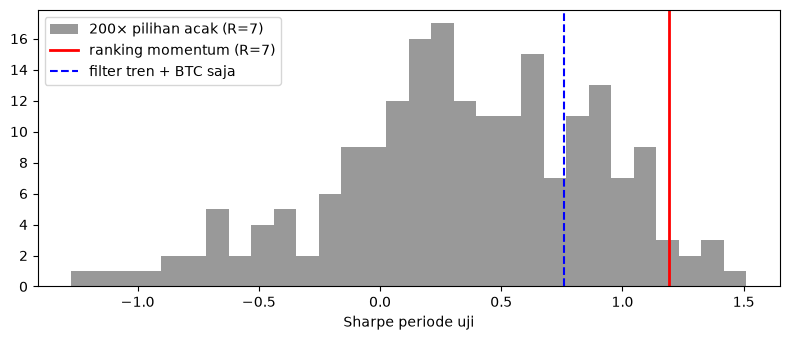

,momentum_return,momentum_sharpe,acak_return_median,acak_sharpe_median,acak_sharpe_p95,p_value
R,,,,,,
7,+140.7%,1.19,+14.7%,0.34,1.09,+3.5%
3,+43.0%,0.62,+17.1%,0.36,1.06,+29.5%


In [6]:
def ranked_target(P, ma_n, L, R, score):
    # Sama dengan f2_target, tapi skor bisa diganti (momentum / acak).
    bc = P.close[BTC]
    regime = (bc > bc.rolling(ma_n, min_periods=ma_n).mean()).to_numpy()
    own = P.close > P.ma(ma_n)
    sc = score.where(own & (P.ret(L) > 0))
    best = sc.fillna(-np.inf).idxmax(axis=1).where(sc.notna().any(axis=1)).to_numpy(dtype=object)
    valid, cols = own.to_numpy(), {s: i for i, s in enumerate(P.syms)}
    out, cur, age = [], None, 0
    for t in range(len(P.dates)):
        age += 1
        b = best[t] if isinstance(best[t], str) else None
        if not regime[t]:
            cur = None
        elif cur is None or not valid[t, cols[cur]] or age >= R:
            if b != cur:
                cur = b
            age = 0
        out.append(cur)
    return pd.Series(out, index=P.dates)


size2 = (0.02 / P.vol(20)).clip(upper=1)
null_rows = []
for R in (7, 3):
    mom = ranked_target(P, 50, 14, R, P.ret(14) / P.vol(14))
    m_mom = metrics(*run(P, mom, *TEST, size=size2, circuit_dd=0.15))
    rng = np.random.default_rng(0)
    rand_ret, rand_sh = [], []
    for _ in range(200):
        rnd = pd.DataFrame(rng.random(P.close.shape), index=P.dates, columns=P.syms)
        m = metrics(*run(P, ranked_target(P, 50, 14, R, rnd), *TEST, size=size2, circuit_dd=0.15))
        rand_ret.append(m["total_return"]); rand_sh.append(m["sharpe"])
    rand_ret, rand_sh = np.array(rand_ret), np.array(rand_sh)
    null_rows.append(dict(R=R, momentum_return=m_mom["total_return"], momentum_sharpe=m_mom["sharpe"],
                          acak_return_median=np.median(rand_ret), acak_sharpe_median=np.median(rand_sh),
                          acak_sharpe_p95=np.percentile(rand_sh, 95),
                          p_value=(rand_sh >= m_mom["sharpe"]).mean()))
    if R == 7:
        rand_sh_7, mom_sh_7 = rand_sh, m_mom["sharpe"]

# pembanding: filter tren saja (pegang BTC saat rezim on) dengan sizing & circuit yang sama
m_regime_btc = metrics(*run(P, hold.where(btc_close > btc_close.rolling(50).mean()), *TEST, size=size2, circuit_dd=0.15))
print(f"Filter tren saja (BTC, sizing 2%, circuit 15%): return {m_regime_btc['total_return']:+.1%}, Sharpe {m_regime_btc['sharpe']:.2f}")
plt.figure(figsize=(8, 3.5))
plt.hist(rand_sh_7, bins=30, color="#999999", label="200× pilihan acak (R=7)")
plt.axvline(mom_sh_7, color="red", lw=2, label="ranking momentum (R=7)")
plt.axvline(m_regime_btc["sharpe"], color="blue", lw=1.5, ls="--", label="filter tren + BTC saja")
plt.xlabel("Sharpe periode uji"); plt.legend(); plt.tight_layout(); plt.show()
pretty(pd.DataFrame(null_rows).set_index("R"), pct=["momentum_return", "acak_return_median", "p_value"],
       dec=["momentum_sharpe", "acak_sharpe_median", "acak_sharpe_p95"])

## 6. Ulangi proses riset 07 **tanpa SUI** dari awal

SUI listing 2023 dan naik besar di 2024 — ia masuk daftar 10 coin karena **sekarang** sudah besar
(survivorship bias). Di sini seluruh proses 07 diulang tanpa SUI: grid 144 → pilih Calmar latih
tertinggi → laporkan periode uji.

In [7]:
P_nosui = Panel({k: v for k, v in ohlc_all.items() if k != "SUIUSDT"}, "2018-01-01", "2026-06-30")
rows = []
for combo in GRID:
    c = dict(zip(GRID_KEYS, combo))
    mt, me = metrics(*sim(P_nosui, c, *TRAIN)), metrics(*sim(P_nosui, c, *TEST))
    rows.append(dict(**c, tr_calmar=mt["calmar"], tr_return=mt["total_return"],
                     te_return=me["total_return"], te_dd=me["max_dd"], te_sharpe=me["sharpe"]))
g_ns = pd.DataFrame(rows)
sel = g_ns.sort_values("tr_calmar", ascending=False).iloc[0]
kons_ns = metrics(*sim(P_nosui, CFG["Konservatif"], *TEST))
print("Tanpa SUI — konfigurasi terpilih dari data latih:", {k: sel[k] for k in GRID_KEYS})
print(f"  hasil uji : return {sel.te_return:+.1%}, DD {sel.te_dd:+.1%}, Sharpe {sel.te_sharpe:.2f}")
print(f"Konservatif (param 07) tanpa SUI: return {kons_ns['total_return']:+.1%}, DD {kons_ns['max_dd']:+.1%}, Sharpe {kons_ns['sharpe']:.2f}")
print(f"Distribusi 144 kombinasi tanpa SUI di uji: median return {g_ns.te_return.median():+.1%}, "
      f"{(g_ns.te_sharpe > btc_test['sharpe']).mean():.0%} Sharpe > BTC, {(g_ns.te_return > 0).mean():.0%} untung")

Tanpa SUI — konfigurasi terpilih dari data latih: {'ma_n': np.float64(50.0), 'L': np.float64(14.0), 'R': np.float64(1.0), 'tv': np.float64(0.03), 'cdd': np.float64(0.15)}
  hasil uji : return +47.1%, DD -41.1%, Sharpe 0.57
Konservatif (param 07) tanpa SUI: return +4.6%, DD -35.2%, Sharpe 0.21
Distribusi 144 kombinasi tanpa SUI di uji: median return +115.6%, 86% Sharpe > BTC, 92% untung


## 7. Ketidakpastian Sharpe — stationary block bootstrap

Return harian periode uji di-resample dalam blok (rata-rata 20 hari, menjaga autokorelasi), 2.000 kali.

In [8]:
def block_bootstrap_sharpe(r, n=2000, mean_block=20, seed=1):
    r = np.asarray(r); T = len(r); rng = np.random.default_rng(seed); out = np.empty(n)
    for k in range(n):
        idx, i = [], rng.integers(T)
        while len(idx) < T:
            idx.append(i)
            i = rng.integers(T) if rng.random() < 1 / mean_block else (i + 1) % T
        out[k] = daily_sharpe(r[idx]) * np.sqrt(365)
    return out

rows = []
for name, c in CFG.items():
    _, eq = sim(P, c, *TEST)
    bs = block_bootstrap_sharpe(eq.pct_change().dropna())
    rows.append(dict(strategi=name, sharpe_p5=np.percentile(bs, 5), sharpe_median=np.median(bs),
                     sharpe_p95=np.percentile(bs, 95), p_sharpe_lt_0=(bs < 0).mean(),
                     p_sharpe_lt_btc=(bs < btc_test["sharpe"]).mean()))
_, eq_b = run(P, hold, *TEST)
bs = block_bootstrap_sharpe(eq_b.pct_change().dropna())
rows.append(dict(strategi="Buy & hold BTC", sharpe_p5=np.percentile(bs, 5), sharpe_median=np.median(bs),
                 sharpe_p95=np.percentile(bs, 95), p_sharpe_lt_0=(bs < 0).mean(), p_sharpe_lt_btc=np.nan))
pretty(pd.DataFrame(rows).set_index("strategi"), pct=["p_sharpe_lt_0", "p_sharpe_lt_btc"],
       dec=["sharpe_p5", "sharpe_median", "sharpe_p95"])

,sharpe_p5,sharpe_median,sharpe_p95,p_sharpe_lt_0,p_sharpe_lt_btc
strategi,,,,,
Konservatif,0.05,1.34,2.42,+4.0%,+12.4%
Agresif,0.15,1.46,2.51,+3.1%,+10.4%
Buy & hold BTC,-0.62,0.45,1.52,+23.4%,-


## 8. Circuit breaker dieksekusi di open hari berikutnya

Di 07, circuit breaker menjual di **close hari yang sama** saat kondisinya terdeteksi. Versi realistis:
kondisi baru diketahui saat close, jual di open besok.

In [9]:
rows = []
for name, c in CFG.items():
    for nxt in (False, True):
        m = metrics(*sim(P, c, *TEST, circuit_next_open=nxt))
        rows.append(dict(strategi=name, eksekusi_circuit="open besok" if nxt else "close hari itu (07)",
                         total_return=m["total_return"], max_dd=m["max_dd"], sharpe=m["sharpe"]))
pretty(pd.DataFrame(rows).set_index(["strategi", "eksekusi_circuit"]), pct=["total_return", "max_dd"], dec=["sharpe"])

total_return  max_dd sharpe
strategi    eksekusi_circuit                               
Konservatif close hari itu (07)      +204.0%  -30.8%   1.37
            open besok               +203.9%  -30.8%   1.37
Agresif     close hari itu (07)      +354.9%  -39.1%   1.49
            open besok               +354.8%  -39.1%   1.49

## Kesimpulan — overfit **sebagian**: idenya nyata, angka & parameter spesifiknya tidak

### Ringkasan hasil uji
| # | Uji | Hasil | Arti |
|---|---|---|---|
| 1 | Kebocoran proses | Dengan data latih saja, F2 tetap juara (median Sharpe 1.17 vs F1 0.79) | ✅ pemilihan keluarga tidak bergantung data uji |
| 2 | **PBO (CSCV)** | **37.2%** — juara in-sample Sharpe 1.95 → out-of-sample 1.28, hampir sama dengan median semua konfigurasi (1.23). Peluang juara rugi di OOS hanya 1% | ⚠️ **menyetel parameter = overfit** (tidak lebih baik dari konfigurasi rata-rata), tapi ✅ hampir semua konfigurasi tetap untung |
| 3 | **Deflated Sharpe** (338 percobaan) | Konservatif **82%**, Agresif 87% | ⚠️ **belum signifikan** di ambang 95% setelah koreksi jumlah percobaan |
| 4 | Walk-forward tahunan | 2022–2026: **+693%** vs BTC +23%, tapi drawdown −48.7% (2022: −28%) | ✅ untung tanpa melihat masa depan, ⚠️ drawdown besar |
| 5 | Uji nol (acak) | R=7: momentum Sharpe 1.19 vs acak median 0.34 (**p = 3.5%**); R=3: p = 29.5% | ✅ ranking momentum menambah nilai nyata (di R=7), tidak konsisten di semua setting |
| 6 | **Tanpa SUI** | Parameter Konservatif 07: **+4.6%**, Sharpe 0.21 (< BTC). Tapi median 144 kombinasi: +116%, 86% Sharpe > BTC | ⚠️ **parameter terpilih 07 rapuh**, ✅ keluarga strategi tetap bekerja |
| 7 | Bootstrap Sharpe | Konservatif 90% CI **[0.05 – 2.42]**; peluang di bawah BTC 12% | ⚠️ ketidakpastian sangat lebar |
| 8 | Circuit di open besok | Tidak berubah (+204% → +203.9%) | ✅ bukan sumber bias |

### Jawaban: apakah 07 "menghafal"?
- **Ya, untuk angka dan parameternya.** Angka +204% / +355% terlalu optimis: sebagian dari
  keberuntungan SUI (survivorship bias) dan sebagian dari memilih parameter terbaik (PBO 37%).
  Parameter Konservatif 07 (L=14, R=1) justru termasuk yang rapuh begitu SUI dibuang.
- **Tidak, untuk idenya.** "Cash saat BTC di bawah MA + pegang coin dengan momentum terkuat saat tren
  naik" bekerja di hampir semua kombinasi parameter, lolos walk-forward, mengalahkan pilihan acak
  (p = 3.5% di R=7), tetap bekerja tanpa SUI (median kombinasi), dan untung di validasi coin produksi (07).
- **Secara statistik belum terbukti kuat** (DSR 82% < 95%) — data 2,5 tahun periode uji terlalu pendek
  untuk kepastian.

### Rekomendasi
1. **Jangan pakai parameter hasil tuning 07 sebagai "angka pasti"**; ekspektasi realistis jauh di bawah
   +204%. Pakai hasil validasi DB (+11.7% di pasar turun) sebagai patokan yang lebih jujur.
2. Pilih parameter berdasarkan **ketahanan, bukan juara**: rebalance **mingguan (R=7)** lebih masuk akal —
   satu-satunya setting yang ranking momentumnya signifikan vs acak, biaya lebih rendah, dan sesuai
   target holding 3–7 hari di spesifikasi.
3. Riset berikutnya (notebook 09) wajib: **universe tanpa survivorship bias** — download histori semua
   coin Large/Mid di `flex_params` (termasuk yang turun/delisting kalau datanya ada), lalu ulangi
   07 + 08 dengan protokol yang sama.
4. **Paper trading / testnet** sebelum modal riil tetap wajib.